# 04 수요패턴 분석 (개요)

**목적:** 5개 매장 **type**(D,B,C,E,A)별 수요 변동성을 **System-Level**(전체)과 **SKU-Level**(family 시계열)로 살펴봅니다.

| 분석 | 내용 |
|------|------|
| System-Level | type별 주간 총판매 통계 (mean, CV, skewness) |
| SKU-Level | type×family 33개 시계열 평균 통계 |
| SBC 미리보기 | ADI/CV² 4분류 분포 (05장 본격 적용 전 탐색) |

> **상세 분석**(RIDR, 수요 밴드, 클러스터별 통계)은 **`12_제품_수요패턴_RIDR_분석.ipynb`**


### ⓪ 환경 설정 및 데이터 로드

주간 `df_weekly.parquet`를 읽고, 5개 매장 type(A~E)을 확인합니다.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 경로 설정
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'code' else NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'code'))
from utils.paths import DATA_PROCESSED
from utils.stats_summary import system_level_weekly_stats, sku_level_weekly_stats
from utils.sbc import compute_sbc_table
from utils.config import filter_selected_types, selected_type_list

# 02장 주간 데이터 로드
dfw = filter_selected_types(pd.read_parquet(DATA_PROCESSED / 'df_weekly.parquet'))  # 실험 대상 2-type(E·C)
types = sorted(dfw['type'].unique())
print('type 개수:', len(types), types)


type 개수: 2 ['C', 'E']


### ① System-Level / SKU-Level 기초통계

type별로:
- **System-Level:** 해당 type 전체 주간 총판매 통계 (논문 Table 3.2)
- **SKU-Level:** 33개 family 시계열 각각의 mean/std/CV → type별 평균 요약

In [2]:
# type별 System-Level(총판매) / SKU-Level(family 시계열) 기초통계
system_rows, sku_rows, sku_detail_all = [], [], []
for t in types:
    sys_df = system_level_weekly_stats(dfw, t)
    sku_sum, sku_detail = sku_level_weekly_stats(dfw, t)
    system_rows.append(sys_df)
    sku_rows.append(sku_sum)
    sku_detail_all.append(sku_detail)

system_stats = pd.concat(system_rows, ignore_index=True)
sku_stats = pd.concat(sku_rows, ignore_index=True)
sku_detail = pd.concat(sku_detail_all, ignore_index=True)

print('=== System-Level (type별 주간 총판매) ===')
print(system_stats.round(3))
print('\n=== SKU-Level 요약 (type별 family 시계열 평균 통계) ===')
print(sku_stats.round(3))


=== System-Level (type별 주간 총판매) ===
  type   level  n_weeks        mean      median         std      variance  \
0    C  system      242  679482.407  719666.369  175910.559  3.094452e+10   
1    E  system      242  247200.148  250152.746  105991.828  1.123427e+10   

      cv  skewness  kurtosis         min          max  
0  0.259    -0.120    -1.087  268354.749  1121222.554  
1  0.429    -0.049    -1.120   51409.921   526891.967  

=== SKU-Level 요약 (type별 family 시계열 평균 통계) ===
  type level  n_series  mean_of_mean  mean_of_std  mean_of_cv  median_of_mean
0    C   sku        33     20590.376     6103.017       0.718         926.368
1    E   sku        33      7490.914     3450.062       0.868         283.492


### ② SBC 패턴 미리보기

type×family 2-type(E·C) 66 시계열에 ADI·CV²를 계산해 4분류 분포를 type별로 확인합니다 (05장 본격 적용 전 탐색).

In [3]:
# ADI/CV² 기반 SBC 4분류 (type×family 165 시계열)
sbc_preview = compute_sbc_table(dfw, ['type', 'family'], qty_col='sales')
print(sbc_preview.groupby(['type', 'SBC_CLUSTER_LABEL']).size().unstack(fill_value=0))
sbc_preview.head(10)


SBC_CLUSTER_LABEL  Erratic  Intermittent  Lumpy  Smooth
type                                                   
C                        1            10      3      19
E                        2             9      3      19


,type,family,ADI,CV2,SBC_CLUSTER,SBC_CLUSTER_LABEL,n_periods,n_positive
0,C,AUTOMOTIVE,1.000000,0.063214,1,Smooth,242,242
1,C,BABY CARE,1.847328,0.370534,2,Intermittent,242,131
2,C,BEAUTY,1.000000,0.168038,1,Smooth,242,242
3,C,BEVERAGES,1.000000,0.187246,1,Smooth,242,242
4,C,BOOKS,NaN,NaN,4,Lumpy,242,0
5,C,BREAD/BAKERY,1.000000,0.012713,1,Smooth,242,242
6,C,CELEBRATION,1.613333,0.036604,2,Intermittent,242,150
7,C,CLEANING,1.000000,0.028400,1,Smooth,242,242
8,C,DAIRY,1.000000,0.123290,1,Smooth,242,242
9,C,DELI,1.000000,0.046555,1,Smooth,242,242


### ③ type별 변동성(CV) 비교

family 시계열 CV의 type별 평균을 비교합니다. **CV가 낮을수록 안정적** 수요 패턴입니다.

type별 평균 CV (낮을수록 안정):
type
C    0.717811
E    0.867512
Name: cv, dtype: float64


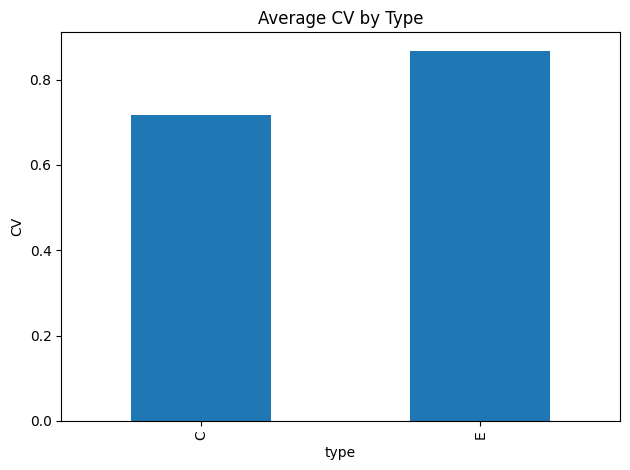

In [4]:
# type별 평균 CV 비교 (낮을수록 안정적 수요)
vol = sku_detail.groupby('type')['cv'].mean().sort_values()
print('type별 평균 CV (낮을수록 안정):')
print(vol)
vol.plot(kind='bar', title='Average CV by Type')
plt.ylabel('CV')
plt.tight_layout()
plt.show()


### ④ 통계 결과 저장

System/SKU-Level 통계를 CSV로 저장합니다. 11장 RIDR 분석의 기초 자료로 활용됩니다.

In [5]:
# 통계 결과 CSV 저장 (11장 RIDR 분석 기초 자료)
out_dir = DATA_PROCESSED
system_stats.to_csv(out_dir / 'type_system_level_stats.csv', index=False)
sku_stats.to_csv(out_dir / 'type_sku_level_stats.csv', index=False)
sku_detail.to_csv(out_dir / 'type_family_series_stats.csv', index=False)
print('저장 완료')


저장 완료


## 분석 요약 (개요)

### System-Level (type별 주간 총판매)
- **type D·A** 규모 최대 (주간 평균 ~145만), **type E** 최소 (~24.7만)
- CV는 **E(0.43) > B(0.34) > D·A(0.30)** → 소규모 type일수록 상대 변동성 큼
- 왜도·첨도 모두 음수에 가까워 **왼쪽 꼬리가 짧은 분포** (극단적 저수요 주가 적음)

### SKU-Level (family 시계열 평균)
- type당 **33개 family** 시계열, 평균 CV는 **E(0.87) > C(0.72) > A(0.65)**
- type D가 평균 CV 최저(0.62) → **가장 안정적인 매장 유형**

### SBC 패턴 미리보기 (type×family)
- 모든 type에서 **Smooth(19개)** 가 가장 많고, **Intermittent(8~10개)** 가 그다음
- Erratic·Lumpy는 type당 1~3개로 소수

> 상세 분석(System/SKU 클러스터 통계, **RIDR**, 수요 밴드)은 **`12_제품_수요패턴_RIDR_분석.ipynb`** 참조